# Feature Engineering
### **Mohon membaca setiap instruksi dan tag komentar dengan saksama sebelum melanjutkan pengerjaan.**

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# B. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [52]:
# untuk plot Q-Q
import scipy.stats as stats

In [53]:
df_california = pd.read_csv('california_dataset.csv')

In [54]:
from sklearn.model_selection import train_test_split
# splitting terlebih dahulu


#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

### Assignment 1.a :
1. lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv
2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

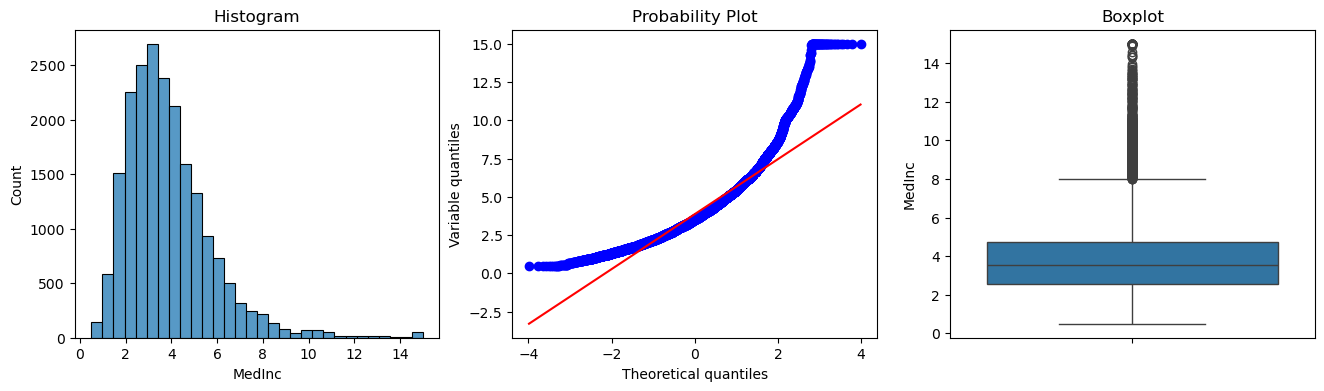

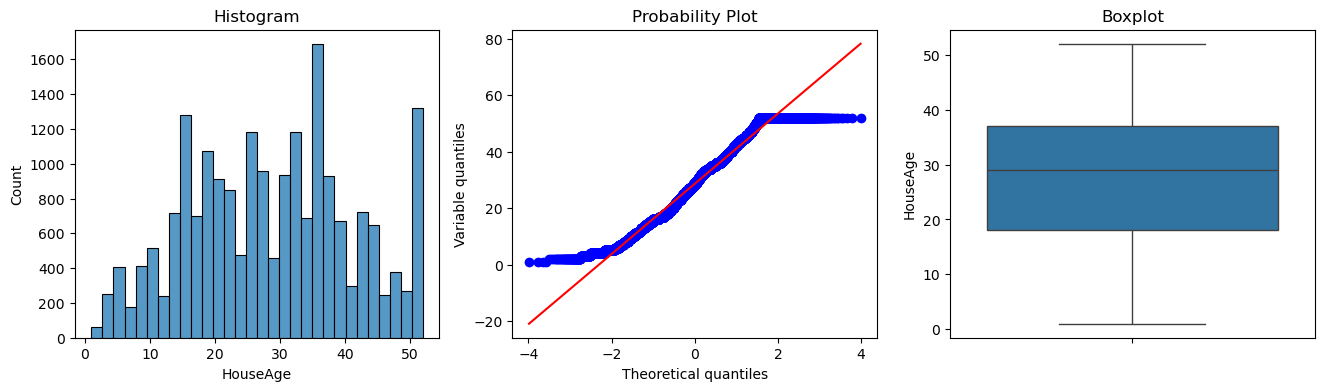

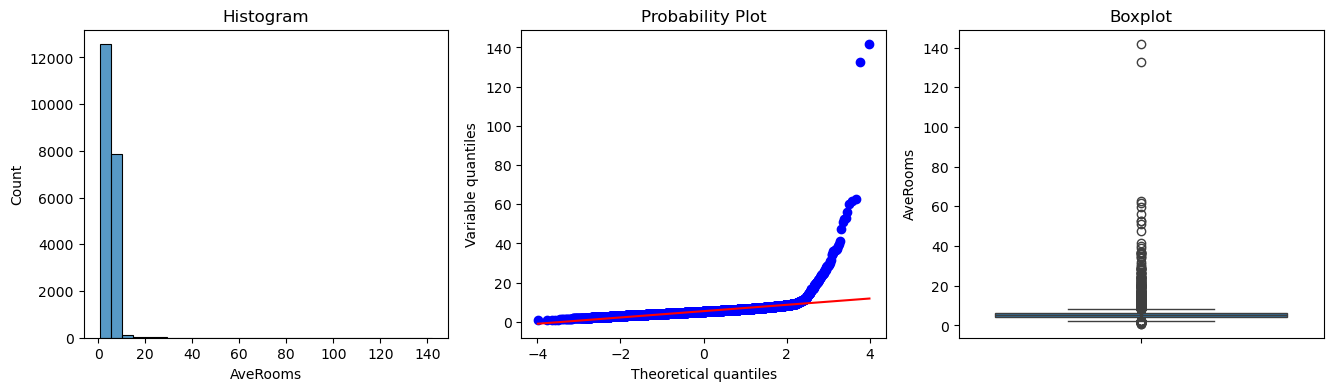

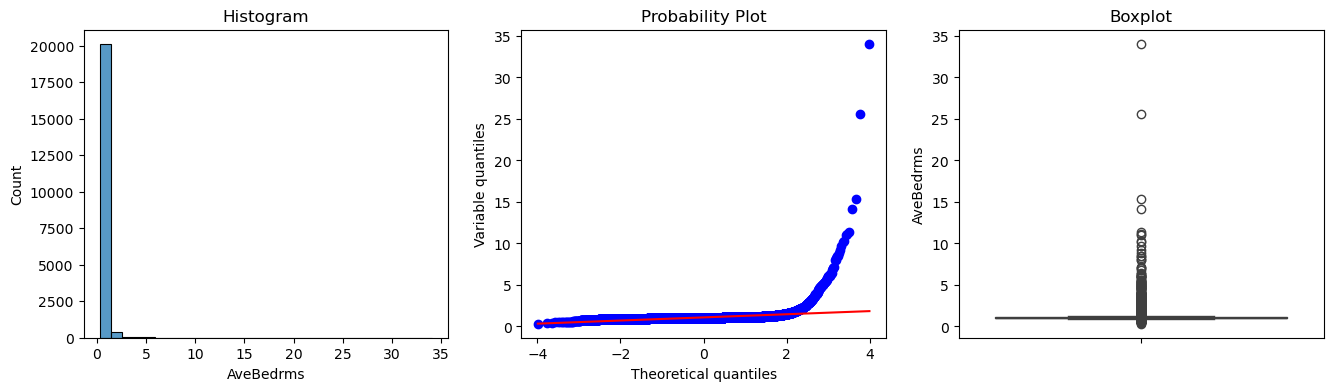

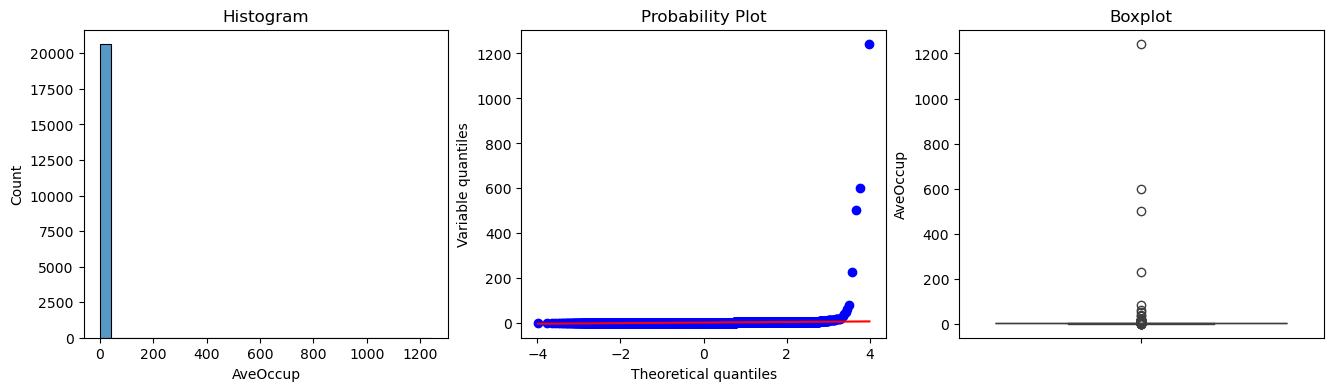

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv('california_dataset.csv')

# Assignment 1.a : lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup'] di california_dataset.csv
# Daftar nama kolom yang ingin Anda cek
columns_columns = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']
def check_plot(df, variable):
    #tentukan ukuran gambar
    plt.figure(figsize=(16, 4))
    # histogram
    plt.subplot(1, 3, 1)
    sns.histplot(df[variable], bins=30)
    plt.title('Histogram')
    # plot Q-Q
    plt.subplot(1, 3, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.ylabel('Variable quantiles')

    # box plot
    plt.subplot(1, 3, 3)
    sns.boxplot(y=df[variable])
    plt.title('Boxplot')

    plt.show()
        
for variable in columns_columns:
    check_plot(df, variable)
        

### Assignment 1.b
1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
2. Dan cek distribusinya kembali

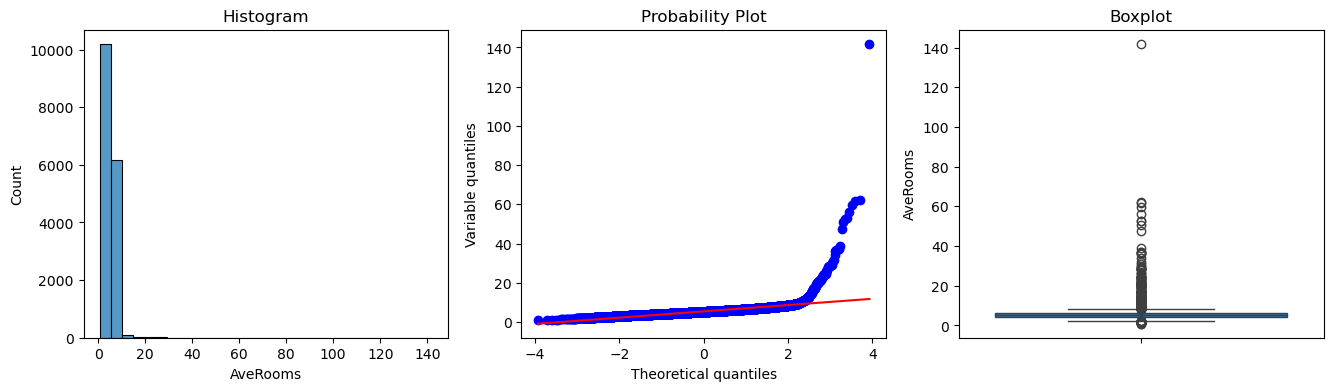

In [56]:
### Assignment 1.b Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_csv('california_dataset.csv')

train_clfr, test_clfr = train_test_split(df, test_size = 0.2, random_state=42)
def check_plot(df, variable):
    # fungsi mengambil kerangka data (df) dan
    # variabel yang diminati sebagai argumen
    # tentukan ukuran gambar
    plt.figure(figsize=(16, 4))

    # histogram
    plt.subplot(1, 3, 1)
    sns.histplot(df[variable], bins=30)
    plt.title('Histogram')

    # plot Q-Q
    plt.subplot(1, 3, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.ylabel('Variable quantiles')

    # box plot
    plt.subplot(1, 3, 3)
    sns.boxplot(y=df[variable])
    plt.title('Boxplot')

    plt.show()
    
### Dan cek distribusinya kembali
check_plot(train_clfr,'AveRooms')
    
def find_outlier_boundary(df, variable):

# Mari kita hitung batas luar yang merupakan outlier
    IQR = df[variable].quantile(0.75) - df[variable].quantile(0.25)

    lower_boundary = df[variable].quantile(0.25) - (IQR * 1.5)
    upper_boundary = df[variable].quantile(0.75) + (IQR * 1.5)

    return upper_boundary, lower_boundary   

AveRooms_upper_limit, AveRooms_lower_limit = find_outlier_boundary(train_clfr, 'AveRooms')
AveRooms_upper_limit, AveRooms_lower_limit

train_clfr['AveRooms'] = np.where(
    train_clfr['AveRooms'] > AveRooms_upper_limit, AveRooms_upper_limit,  # Jika lebih besar dari batas atas, ganti dengan batas atas
    np.where(
        train_clfr['AveRooms'] < AveRooms_lower_limit, AveRooms_lower_limit,  # Jika lebih kecil dari batas bawah, ganti dengan batas bawah
        train_clfr['AveRooms']  # Jika tidak outlier, biarkan tetap sama
    )
)
 

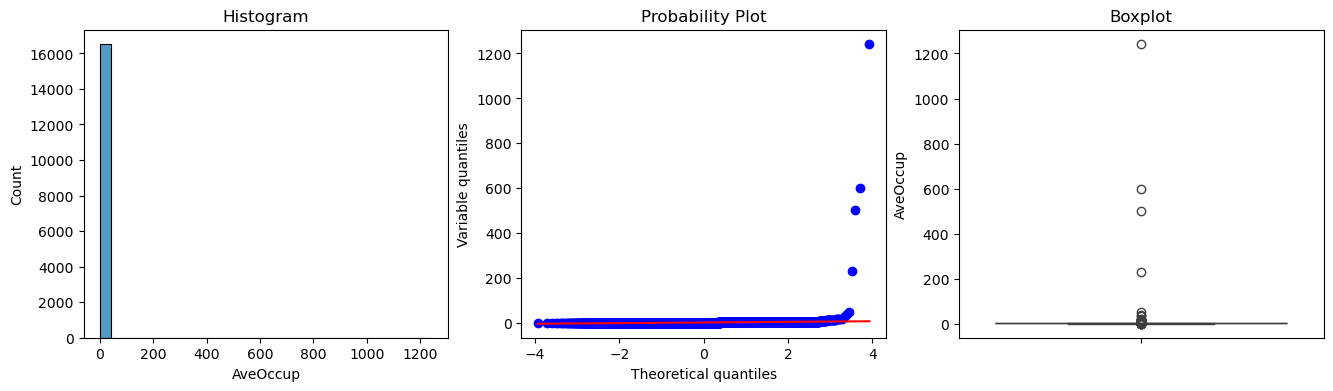

In [57]:
# Melakukan loop untuk mengecek distribusi tiap kolom
import numpy as np

train_clfr['AveRooms'] = np.where(
    train_clfr['AveRooms'] > AveRooms_upper_limit, AveRooms_upper_limit,  # Jika lebih besar dari batas atas, ganti dengan batas atas
    np.where(
        train_clfr['AveRooms'] < AveRooms_lower_limit, AveRooms_lower_limit,  # Jika lebih kecil dari batas bawah, ganti dengan batas bawah
        train_clfr['AveRooms']  # Jika tidak outlier, biarkan tetap sama
    )
)

check_plot(train_clfr, variable)
    

# C. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

In [58]:
df_company = pd.read_csv('company.csv')

### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

In [59]:
from sklearn.model_selection import train_test_split
#Splitting terlebih dahulu

#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)

## Assignment 2. Missing Value Handling :
1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?

In [60]:
#Tulis jawaban missing value handling kolom Headquarters disini
import pandas as pd

df_company = pd.read_csv('company.csv')
df_company.isna().sum()
for column in df_company.columns:
    print(f"============= {column} =================")
    display(df_company[column].value_counts(dropna=False))
    print()

missing_persentase = 100 * len(df_company[df_company['Headquarters'].isin(['-1','Unknown'])]) / len(df_company)
print("Persentase missing value Headquarters:", missing_persentase, "%")

============= Revenue =================


Revenue
Unknown / Non-Applicable            213
$100 to $500 million (USD)           94
$10+ billion (USD)                   63
$2 to $5 billion (USD)               45
$10 to $25 million (USD)             41
$1 to $2 billion (USD)               36
$25 to $50 million (USD)             36
$50 to $100 million (USD)            31
$1 to $5 million (USD)               31
-1                                   27
$500 million to $1 billion (USD)     19
$5 to $10 million (USD)              14
Less than $1 million (USD)           14
$5 to $10 billion (USD)               8
Name: count, dtype: int64


============= Size =================


Size
51 to 200 employees        135
1001 to 5000 employees     104
1 to 50 employees           86
201 to 500 employees        85
10000+ employees            80
501 to 1000 employees       77
5001 to 10000 employees     61
-1                          27
Unknown                     17
Name: count, dtype: int64


============= Rating =================


Rating
 3.5    58
-1.0    50
 4.0    41
 3.3    41
 3.9    40
 3.8    39
 3.7    38
 5.0    36
 4.5    32
 3.6    31
 3.4    31
 4.2    29
 4.1    25
 4.4    24
 4.7    22
 3.2    21
 4.8    20
 4.3    14
 2.9    14
 4.6    12
 3.1    12
 4.9    11
 2.7    10
 3.0     7
 2.6     4
 2.8     3
 2.5     2
 2.2     1
 2.4     1
 2.3     1
 2.1     1
 2.0     1
Name: count, dtype: int64


============= Headquarters =================


Headquarters
New York, NY                 33
-1                           31
San Francisco, CA            31
Chicago, IL                  23
Boston, MA                   19
Reston, VA                   14
Mc Lean, VA                  13
Westminster, CO              12
Cambridge, United Kingdom    10
Cambridge, MA                10
Vienna, VA                    8
Denver, CO                    7
Herndon, VA                   7
Washington, DC                7
Woodbine, MD                  7
Saint Louis, MO               7
Bedford, MA                   7
Arlington, VA                 7
San Jose, CA                  7
San Antonio, TX               6
Mountain View, CA             6
Basel, Switzerland            6
San Rafael, CA                6
Chantilly, VA                 6
Fairfax, VA                   5
Houston, TX                   5
Pittsburgh, PA                5
Bethesda, MD                  5
Rockville, MD                 5
Los Angeles, CA               5
Springfield, MA            


Persentase missing value Headquarters: 4.613095238095238 %


In [61]:
#drop nilai >20%
if missing_persentase>20:
    df_company = df_company.drop(columns=['Headquarters'])
    df_company.info()
    print("columns Headquarters di drop karena missing valuenya >20%")
else:
    print("columns Headquarters tidak di drop karena missing valuenya <20%")
    
from sklearn.model_selection import train_test_split
train_company, test_company = train_test_split(df_company, test_size = 0.2, random_state=42)

# Imputasi modus pada kolom Headquarters : train
modus_Headquarters_train = train_company['Headquarters'].mode()[0]
modus_Headquarters_train
print("Modus Headquarters:", modus_Headquarters_train)

#menerapkan imputasi nilai yang hilang untuk melatih dan menguji, dari pemeringkatan nilai median dalam data train
train_company['Headquarters'] = train_company['Headquarters'].apply(lambda x: modus_Headquarters_train if x==-1 else x) #train
test_company['Headquarters'] = test_company['Headquarters'].apply(lambda x: modus_Headquarters_train if x==-1 else x) #test
train_company['Headquarters'].value_counts()


columns Headquarters tidak di drop karena missing valuenya <20%
Modus Headquarters: New York, NY


Headquarters
New York, NY                 29
San Francisco, CA            28
-1                           24
Chicago, IL                  20
Boston, MA                   13
Mc Lean, VA                  12
Westminster, CO              10
Reston, VA                    9
Cambridge, MA                 8
Cambridge, United Kingdom     8
Vienna, VA                    7
Bedford, MA                   7
San Jose, CA                  7
Woodbine, MD                  6
Mountain View, CA             6
Herndon, VA                   6
Saint Louis, MO               6
Arlington, VA                 6
Washington, DC                6
San Antonio, TX               5
Los Angeles, CA               5
Denver, CO                    5
Chantilly, VA                 5
Bethesda, MD                  5
Orlando, FL                   4
Houston, TX                   4
San Rafael, CA                4
Pittsburgh, PA                4
Bellevue, WA                  4
McLean, VA                    4
Princeton, NJ              

# D. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :
1. One Hot Encoding (OHE) : Lakukan pada kolom gender
2. Label Encoding / Ordinal Encoding : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.
3. Mean Encoding : Contract

In [62]:
df_churn = pd.read_csv('Telco-Customer-Churn.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'Telco-Customer-Churn.csv'

In [ ]:
#Splitting terlebih dahulu


## Assignment 3.a Label Encoder :
1. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines
2. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts
3. Kemudian lakukan label Encoder
4. Notes : gunakan Telco-Customer-Churn.csv

In [ ]:
#Tulis jawaban
import pandas as pd
from sklearn.preprocessing import LabelEncoder
df_churn = pd.read_csv('TelcoCustomerChurn.csv')
df_churn.head(6)
#pilih kolom
custom_columns = ['StreamingMovies','StreamingTV','TechSupport','DeviceProtection','OnlineBackup','OnlineSecurity','MultipleLines']
for column in custom_columns:
    print(f"============= {column} =================")
    print()

============= StreamingMovies =================

============= StreamingTV =================

============= TechSupport =================

============= DeviceProtection =================

============= OnlineBackup =================

============= OnlineSecurity =================

============= MultipleLines =================



In [ ]:
df_churn['StreamingMovies'] = df_churn['StreamingMovies'].replace({'No internet service':'No'})
df_churn['StreamingTV'] = df_churn['StreamingTV'].replace({'No internet service':'No'})
df_churn['TechSupport'] = df_churn['TechSupport'].replace({'No internet service':'No'})
df_churn['DeviceProtection'] = df_churn['DeviceProtection'].replace({'No internet service':'No'})
df_churn['OnlineBackup'] = df_churn['OnlineBackup'].replace({'No internet service':'No'})
df_churn['OnlineSecurity'] = df_churn['OnlineSecurity'].replace({'No internet service':'No'})
df_churn['MultipleLines'] = df_churn['MultipleLines'].replace({'No phone service':'No'})

#Cek nilai-nilai di kolom kategorikal
for column in custom_columns:
    print(f"============= {column} =================")
    display(df_churn[column].value_counts())
    print()

============= StreamingMovies =================


StreamingMovies
No     4311
Yes    2732
Name: count, dtype: int64


============= StreamingTV =================


StreamingTV
No     4336
Yes    2707
Name: count, dtype: int64


============= TechSupport =================


...

OnlineBackup
No     4614
Yes    2429
Name: count, dtype: int64


============= OnlineSecurity =================


OnlineSecurity
No     5024
Yes    2019
Name: count, dtype: int64


============= MultipleLines =================


MultipleLines
No     4072
Yes    2971
Name: count, dtype: int64

In [ ]:
# Kolom-kolom yang ingin di-label encode
columns_to_encode = ['StreamingMovies','StreamingTV','TechSupport','DeviceProtection','OnlineBackup','OnlineSecurity','MultipleLines']

# Inisialisasi LabelEncoder
label_encoder = LabelEncoder()


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

train_churn, test_churn = train_test_split(df_churn, test_size = 0.2, random_state = 42)
# Kolom-kolom yang ingin di one-hot encoding
encode_ohe = ['gender'] #buat list nama-nama kolom yang ingin dilakukan OHE
train_churn = pd.get_dummies(train_churn, columns=encode_ohe, dtype=int)
test_churn = pd.get_dummies(test_churn, columns=encode_ohe, dtype=int)

# Kolom-kolom yang ingin di-label encode
columns_to_encode = ['StreamingMovies','StreamingTV','TechSupport','DeviceProtection','OnlineBackup','OnlineSecurity','MultipleLines']

# Inisialisasi LabelEncoder
label_encoder = LabelEncoder()

#Menerapkan label encoding ke data pelatihan (train)
for col in columns_to_encode:
    
    #fit dilakukan di data train dan implementasikan ke train, kemudian lakukan transform ke data test Untuk mencegah data leakage
    train_churn[col] = label_encoder.fit_transform(train_churn[col])
    
    # Menerapkan label encoding yang sama ke data uji (test)
    test_churn[col] = label_encoder.transform(test_churn[col])
    
# Melakukan one-hot encoding pada kolom "gender"
train_churn.head()
test_churn.head()

,customerID,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male
185,1024-GUALD,0,Yes,No,1,No,1,DSL,0,0,0,0,0,0,Month-to-month,Yes,Electronic check,24.80,24.8,Yes,1,0
2715,0484-JPBRU,0,No,No,41,Yes,2,No,1,1,1,1,1,1,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,No,0,1
3825,3620-EHIMZ,0,Yes,Yes,52,Yes,0,No,1,1,1,1,1,1,Two year,No,Mailed check,19.35,1031.7,No,1,0
1807,6910-HADCM,0,No,No,1,Yes,0,Fiber optic,0,0,2,0,0,0,Month-to-month,No,Electronic check,76.35,76.35,Yes,1,0
132,8587-XYZSF,0,No,No,67,Yes,0,DSL,0,0,0,2,0,0,Two year,No,Bank transfer (automatic),50.55,3260.1,No,0,1


## Selesai :)